In [1]:
pip install -U kaleido

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [3]:
# Dataframe of Crime Severity Index Data for 2019-2024 from Statistics Canada 
# [https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=3510002601&pickMembers%5B0%5D=1.1&cubeTimeFrame.startYear=2019&cubeTimeFrame.endYear=2024&referencePeriods=20190101%2C20240101]

VCSI_data = {
    'Year': ['2019', '2020', '2021', '2022', '2023', '2024'],
    'Violent Crime Severity Index': [90.24, 87.99, 93.40, 99.07, 100.92, 99.87],
    'Percent Change in Violent Crime Severity Index': [8.02, -2.49, 6.15, 6.07, 1.87, -1.04],
    'Youth Violent Crime Severity Index': [79.71, 66.46, 64.32, 83.21, 86.82, 83.28],
    'Percent Change in Youth Violent Crime Severity Index': [3.16, -16.62, -3.22, 29.37, 4.34, -4.08],
    'Non-Violent Crime Severity Index': [75.75, 68.68, 68.10, 71.32, 74.00, 69.76],
    'Percent Change in Non-Violent Crime Severity Index': [4.40, -9.33, -0.84, 4.73, 3.76, -5.73]
}

In [4]:
df = pd.DataFrame(VCSI_data)

df.head()

,Year,Violent Crime Severity Index,Percent Change in Violent Crime Severity Index,Youth Violent Crime Severity Index,Percent Change in Youth Violent Crime Severity Index,Non-Violent Crime Severity Index,Percent Change in Non-Violent Crime Severity Index
0,2019,90.24,8.02,79.71,3.16,75.75,4.40
1,2020,87.99,-2.49,66.46,-16.62,68.68,-9.33
2,2021,93.40,6.15,64.32,-3.22,68.10,-0.84
3,2022,99.07,6.07,83.21,29.37,71.32,4.73
4,2023,100.92,1.87,86.82,4.34,74.00,3.76


In [5]:
import plotly.graph_objects as go
import nbformat
import plotly.graph_objects as go

In [14]:

# Data labels for most recent and oldest data points in each plot line - ChatGPT had to help with this one

labels_overall = [str(v) if y in ['2019','2024'] else '' for y,v in zip(df['Year'], df['Violent Crime Severity Index'])]
labels_youth = [str(v) if y in ['2019','2024'] else '' for y,v in zip(df['Year'], df['Youth Violent Crime Severity Index'])]

graph = go.Figure()

# Defined plot line for Overall Violent Crime Severity Index data

graph.add_trace(go.Scatter(
    x=df['Year'], 
    y=df['Violent Crime Severity Index'], 
    name='Overall VCSI', 
    line_color='darkblue',
    mode='lines+markers+text', # data labels and characteristics
    text=labels_overall,
    textposition='top center',
    textfont=dict(size=12,color='black')))

# Defined plot line for Youth Violent Crime Severity Index Data

graph.add_trace(go.Scatter(
    x=df['Year'], 
    y=df['Youth Violent Crime Severity Index'], 
    name='Youth VCSI', 
    line_color='darkorange',
    mode='lines+markers+text',
    text=labels_youth,
    textposition='top center',
    textfont = dict(size=12, color='black')))

# Defined graph layout

graph.update_layout(
    title = dict(
        text='Canadian Violent Crime Severity Index (VCSI) 2019 to 2024', # Graph title characteristics
        x=0.45,           
        xanchor='center',
        yanchor='top',
        font=dict(size=18, weight='bold')),
    xaxis_title = dict( # X axis title charcateristics
        text= 'Year',
        font=dict(size=14, family='Arial Black')),
    yaxis_title = dict( # Y axis title characteristics
        text='VCSI Score',
        font=dict(size=14, family='Arial Black')),
    width=900,   # Figure dimensions
    height=500,
    margin=dict(
        l=80,   # left margin
        r=80,   # right margin
        t=100,  # top margin
        b=150)) # bottom margin
    

# Graph annotation box

graph.add_annotation(
    text=("Note that emergency measures due to the Covid-19 pandemic were in effect from March 2020 to October 2022.<br>"
          "Data from Statistics Canada: [Table 35-10-0026-01],<br>"
          "Crime severity index and weighted clearance rates, Canada, provinces, territories and Census Metropolitan Areas.<br>"
          " DOI: https://doi.org/10.25318/3510002601-eng"),
    xref="paper",
    yref="paper",
    x=0.5,        # center horizontally
    y=-0.55,      # position below the chart
    showarrow=False,
    font=dict(size=12),
    align="center",
    bordercolor="black",
    borderwidth=1,
    borderpad=6,
    bgcolor="lightyellow",
    opacity=0.9
)



In [ ]:
# save as JPG file

graph.write_image("visualization_1(a).jpg", width=900, height=500, scale=2)

In [7]:
import numpy as np
import matplotlib.pyplot as plt


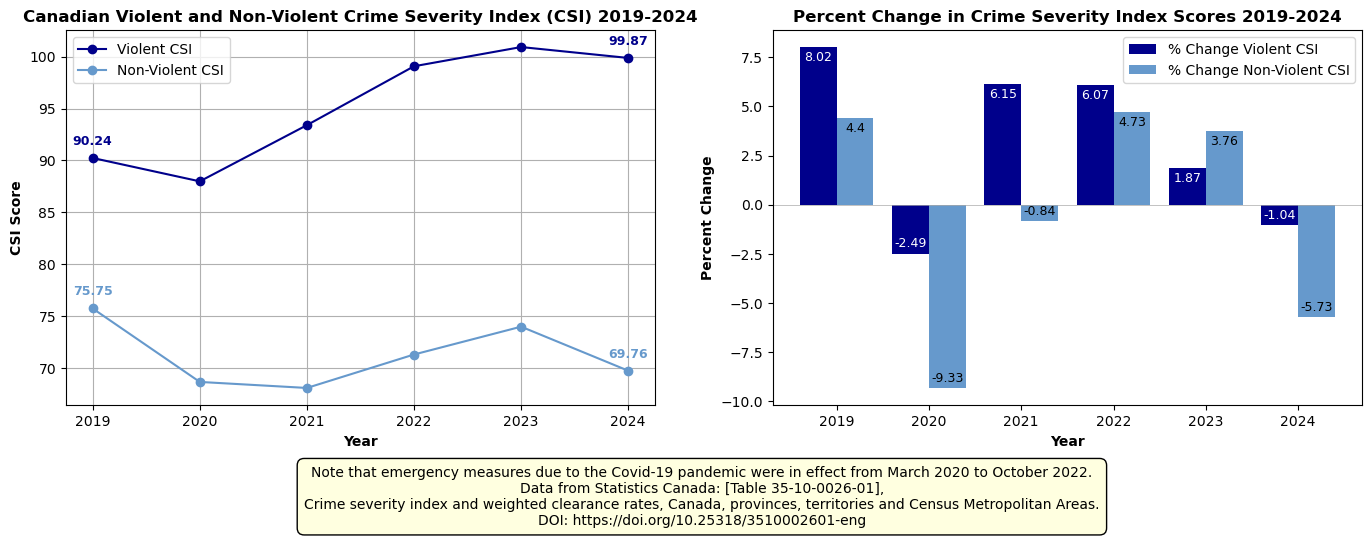

In [ ]:
# Figure characteristics for double graph visualization

fig, (ax1, ax2) = plt.subplots(ncols=2, # two graphs
                               nrows = 1,
                               figsize=(12,5))

plt.subplots_adjust(left=0.22, right=1.3, top=1, bottom=0.25, wspace=0.2)

# Line graph comparing violent and non-violent crime severity index scores

ax1.plot(df['Year'], df['Violent Crime Severity Index'], marker='o', color='darkblue', label= "Violent CSI")
ax1.plot(df['Year'], df['Non-Violent Crime Severity Index'], marker='o', color='#6699CC', label = "Non-Violent CSI")

ax1.set_title("Canadian Violent and Non-Violent Crime Severity Index (CSI) 2019-2024", fontweight='bold')
ax1.set_xlabel("Year", fontweight='bold')
ax1.set_ylabel("CSI Score", fontweight='bold')
ax1.legend()
ax1.grid(True)

# Line graph data labels - Again ChatGPT had to help with this one 

for year, val in zip(df['Year'], df['Violent Crime Severity Index']):
    if year in ['2019', '2024']:
        ax1.text(year, val + 1, f"{val:.2f}", ha='center', va='bottom', fontsize=9, color='darkblue', fontweight='bold')

for year, val in zip(df['Year'], df['Non-Violent Crime Severity Index']):
    if year in ['2019', '2024']:
        ax1.text(year, val + 1, f"{val:.2f}", ha='center', va='bottom', fontsize=9, color='#6699CC', fontweight='bold')

# Bar chart comparing perecent change in violent and non-violent crime severity index scores

x = np.arange(len(df['Year']))  # order for bars
width = 0.40  # width of bars

bars1=ax2.bar(x - width/2, df['Percent Change in Violent Crime Severity Index'], width, label="% Change Violent CSI", color='darkblue')
bars2=ax2.bar(x + width/2, df['Percent Change in Non-Violent Crime Severity Index'], width, label="% Change Non-Violent CSI", color='#6699CC')

ax2.set_xticks(x)
ax2.set_xticklabels(df['Year'])
ax2.set_title('Percent Change in Crime Severity Index Scores 2019-2024', fontweight='bold')
ax2.set_xlabel('Year', fontweight='bold')
ax2.set_ylabel('Percent Change', fontweight='bold')
ax2.legend()
ax2.grid(False)
ax2.axhline(y=0, color='darkgrey', linewidth=0.5)  # axis line at y=0

# Bar graph data labels

ax2.bar_label(bars1, label_type = 'edge', padding=-12, color='white', fontsize=9)
ax2.bar_label(bars2, label_type= 'edge', padding=-12, fontsize=9)

# Graph Annotation Box

fig.text(0.75, 0.01,"Note that emergency measures due to the Covid-19 pandemic were in effect from March 2020 to October 2022.\n"
         "Data from Statistics Canada: [Table 35-10-0026-01],\n"
         "Crime severity index and weighted clearance rates, Canada, provinces, territories and Census Metropolitan Areas.\n"
         "DOI: https://doi.org/10.25318/3510002601-eng", 
         ha='center', 
         fontsize=10, 
         bbox=dict(
             facecolor='lightyellow', 
             edgecolor='black', 
             boxstyle='round,pad=0.5'))

# Save to JPG file

fig.savefig("visualization_1(b).jpg", bbox_inches='tight', pad_inches=0.5, dpi=300) 

plt.show()